# **Descriptive Analysis**

## **1. Import libraries**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## **2. Load Dataset**

In [3]:
df = pd.read_csv("dataset\\digital_marketing_campaign_dataset.csv").drop(columns=["CustomerID", "AdvertisingPlatform", "AdvertisingTool"])
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df

Rows: 8000, Columns: 17


,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21,Male,24849,Email,Awareness,8518.308575,0.243792,0.116773,23,9.693602,14.227794,70,13,6,7,286,0
7996,43,Female,44718,SEO,Retention,1424.613446,0.236740,0.190061,49,9.499010,3.501106,52,13,1,5,1502,0
7997,28,Female,125471,Referral,Consideration,4609.534635,0.056526,0.133826,35,2.853241,14.618323,38,16,0,3,738,1
7998,19,Female,107862,PPC,Consideration,9476.106354,0.023961,0.138386,49,1.002964,3.876623,86,1,5,7,2709,1


## **3. Overal Summary and Statistical values**

In [4]:
# Check for missing values of each columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                8000 non-null   int64  
 1   Gender             8000 non-null   str    
 2   Income             8000 non-null   int64  
 3   CampaignChannel    8000 non-null   str    
 4   CampaignType       8000 non-null   str    
 5   AdSpend            8000 non-null   float64
 6   ClickThroughRate   8000 non-null   float64
 7   ConversionRate     8000 non-null   float64
 8   WebsiteVisits      8000 non-null   int64  
 9   PagesPerVisit      8000 non-null   float64
 10  TimeOnSite         8000 non-null   float64
 11  SocialShares       8000 non-null   int64  
 12  EmailOpens         8000 non-null   int64  
 13  EmailClicks        8000 non-null   int64  
 14  PreviousPurchases  8000 non-null   int64  
 15  LoyaltyPoints      8000 non-null   int64  
 16  Conversion         8000 non-null   

**Conclusion:** according to the general information of the dataeset, it can be seen that the dataset contains 0 missing value

In [5]:
df.describe()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


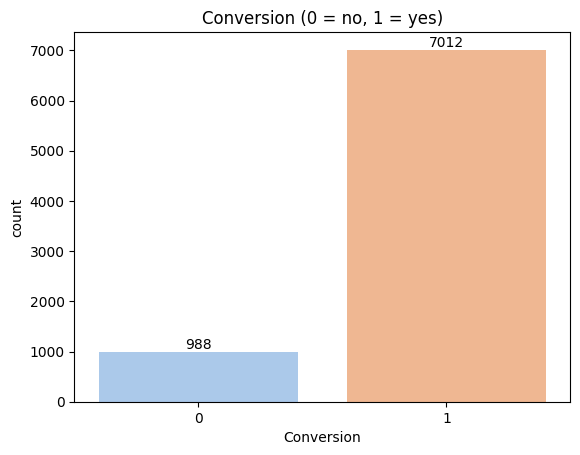

In [6]:
ax = sns.countplot(data=df, x="Conversion", hue="Conversion", palette="pastel", legend=False)
plt.title("Conversion (0 = no, 1 = yes)")
for container in ax.containers:
    ax.bar_label(container)


**Conclusion:** the data is heavily imbalanced, the models' performance can be affected.

## **4. Distribution of numerical data**

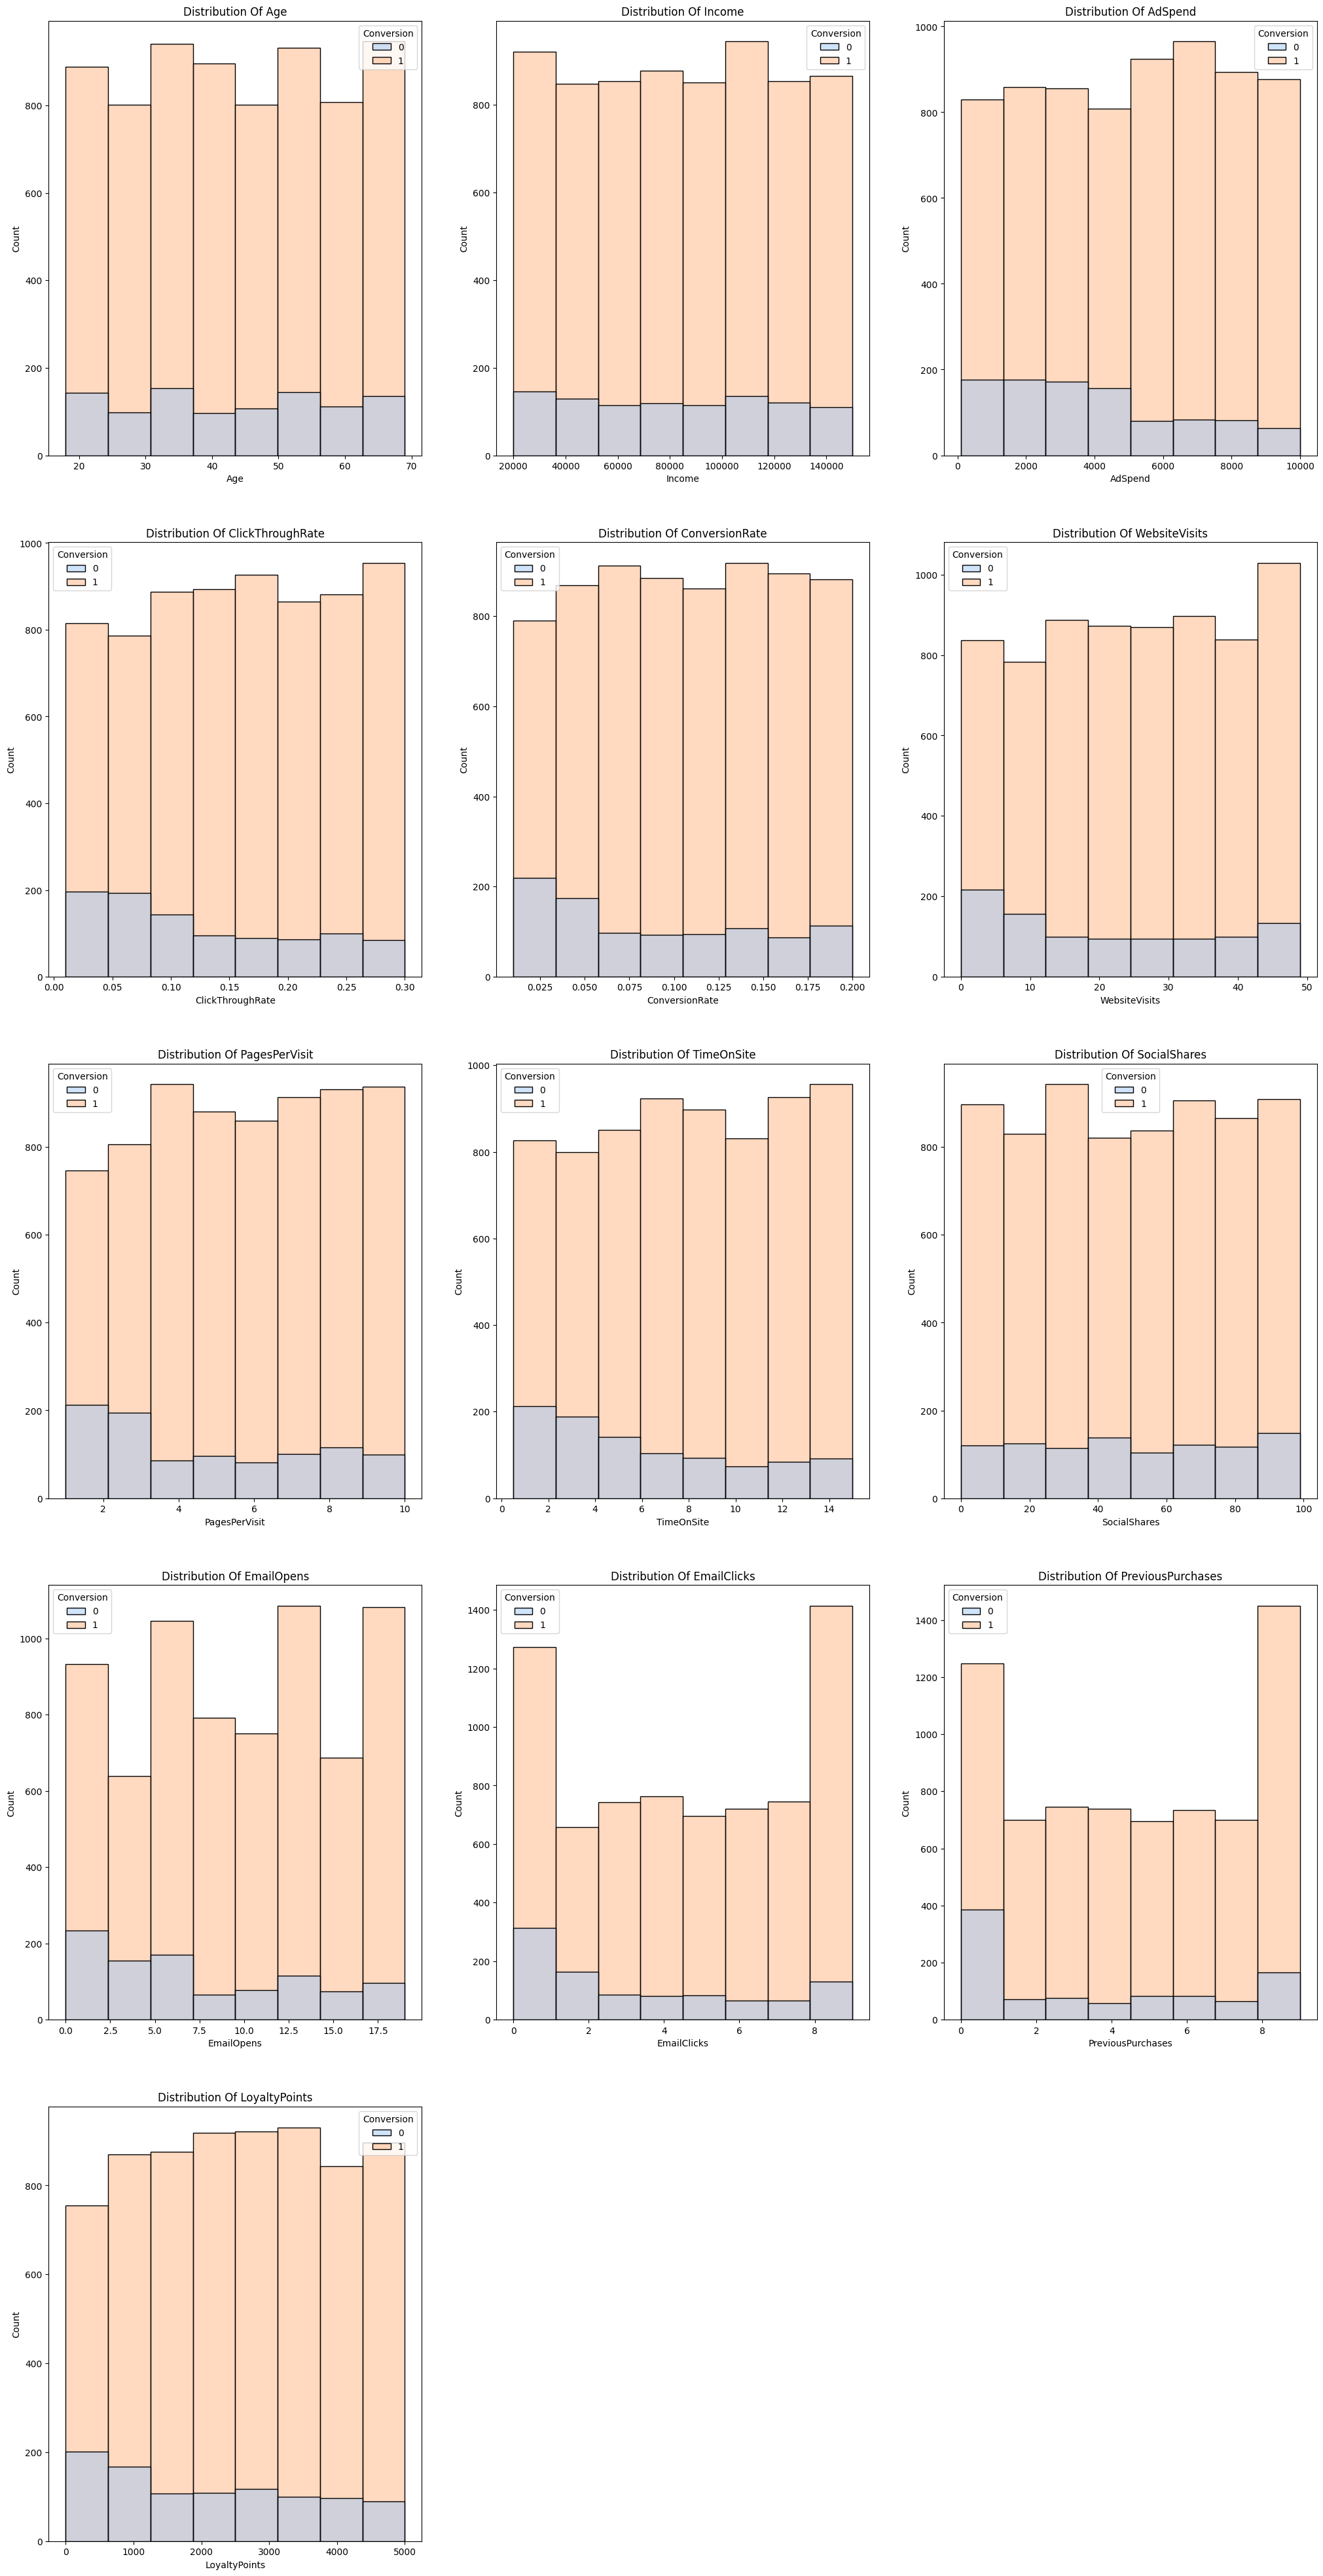

In [13]:

num_vars = df.select_dtypes(include=[np.number]).drop(columns=["Conversion"]).columns
fig, axes = plt.subplots(5, 3, figsize=(25, 50))
axes = axes.flatten()

for i, v in enumerate(num_vars):
    sns.histplot(data=df, x=v, palette="pastel", ax=axes[i], hue="Conversion", bins = 8)
    axes[i].set_title(f"Distribution Of {v}")


for ax in axes[len(num_vars):]:
    fig.delaxes(ax)


## **4. Analysis for customer's demographic and conversion**

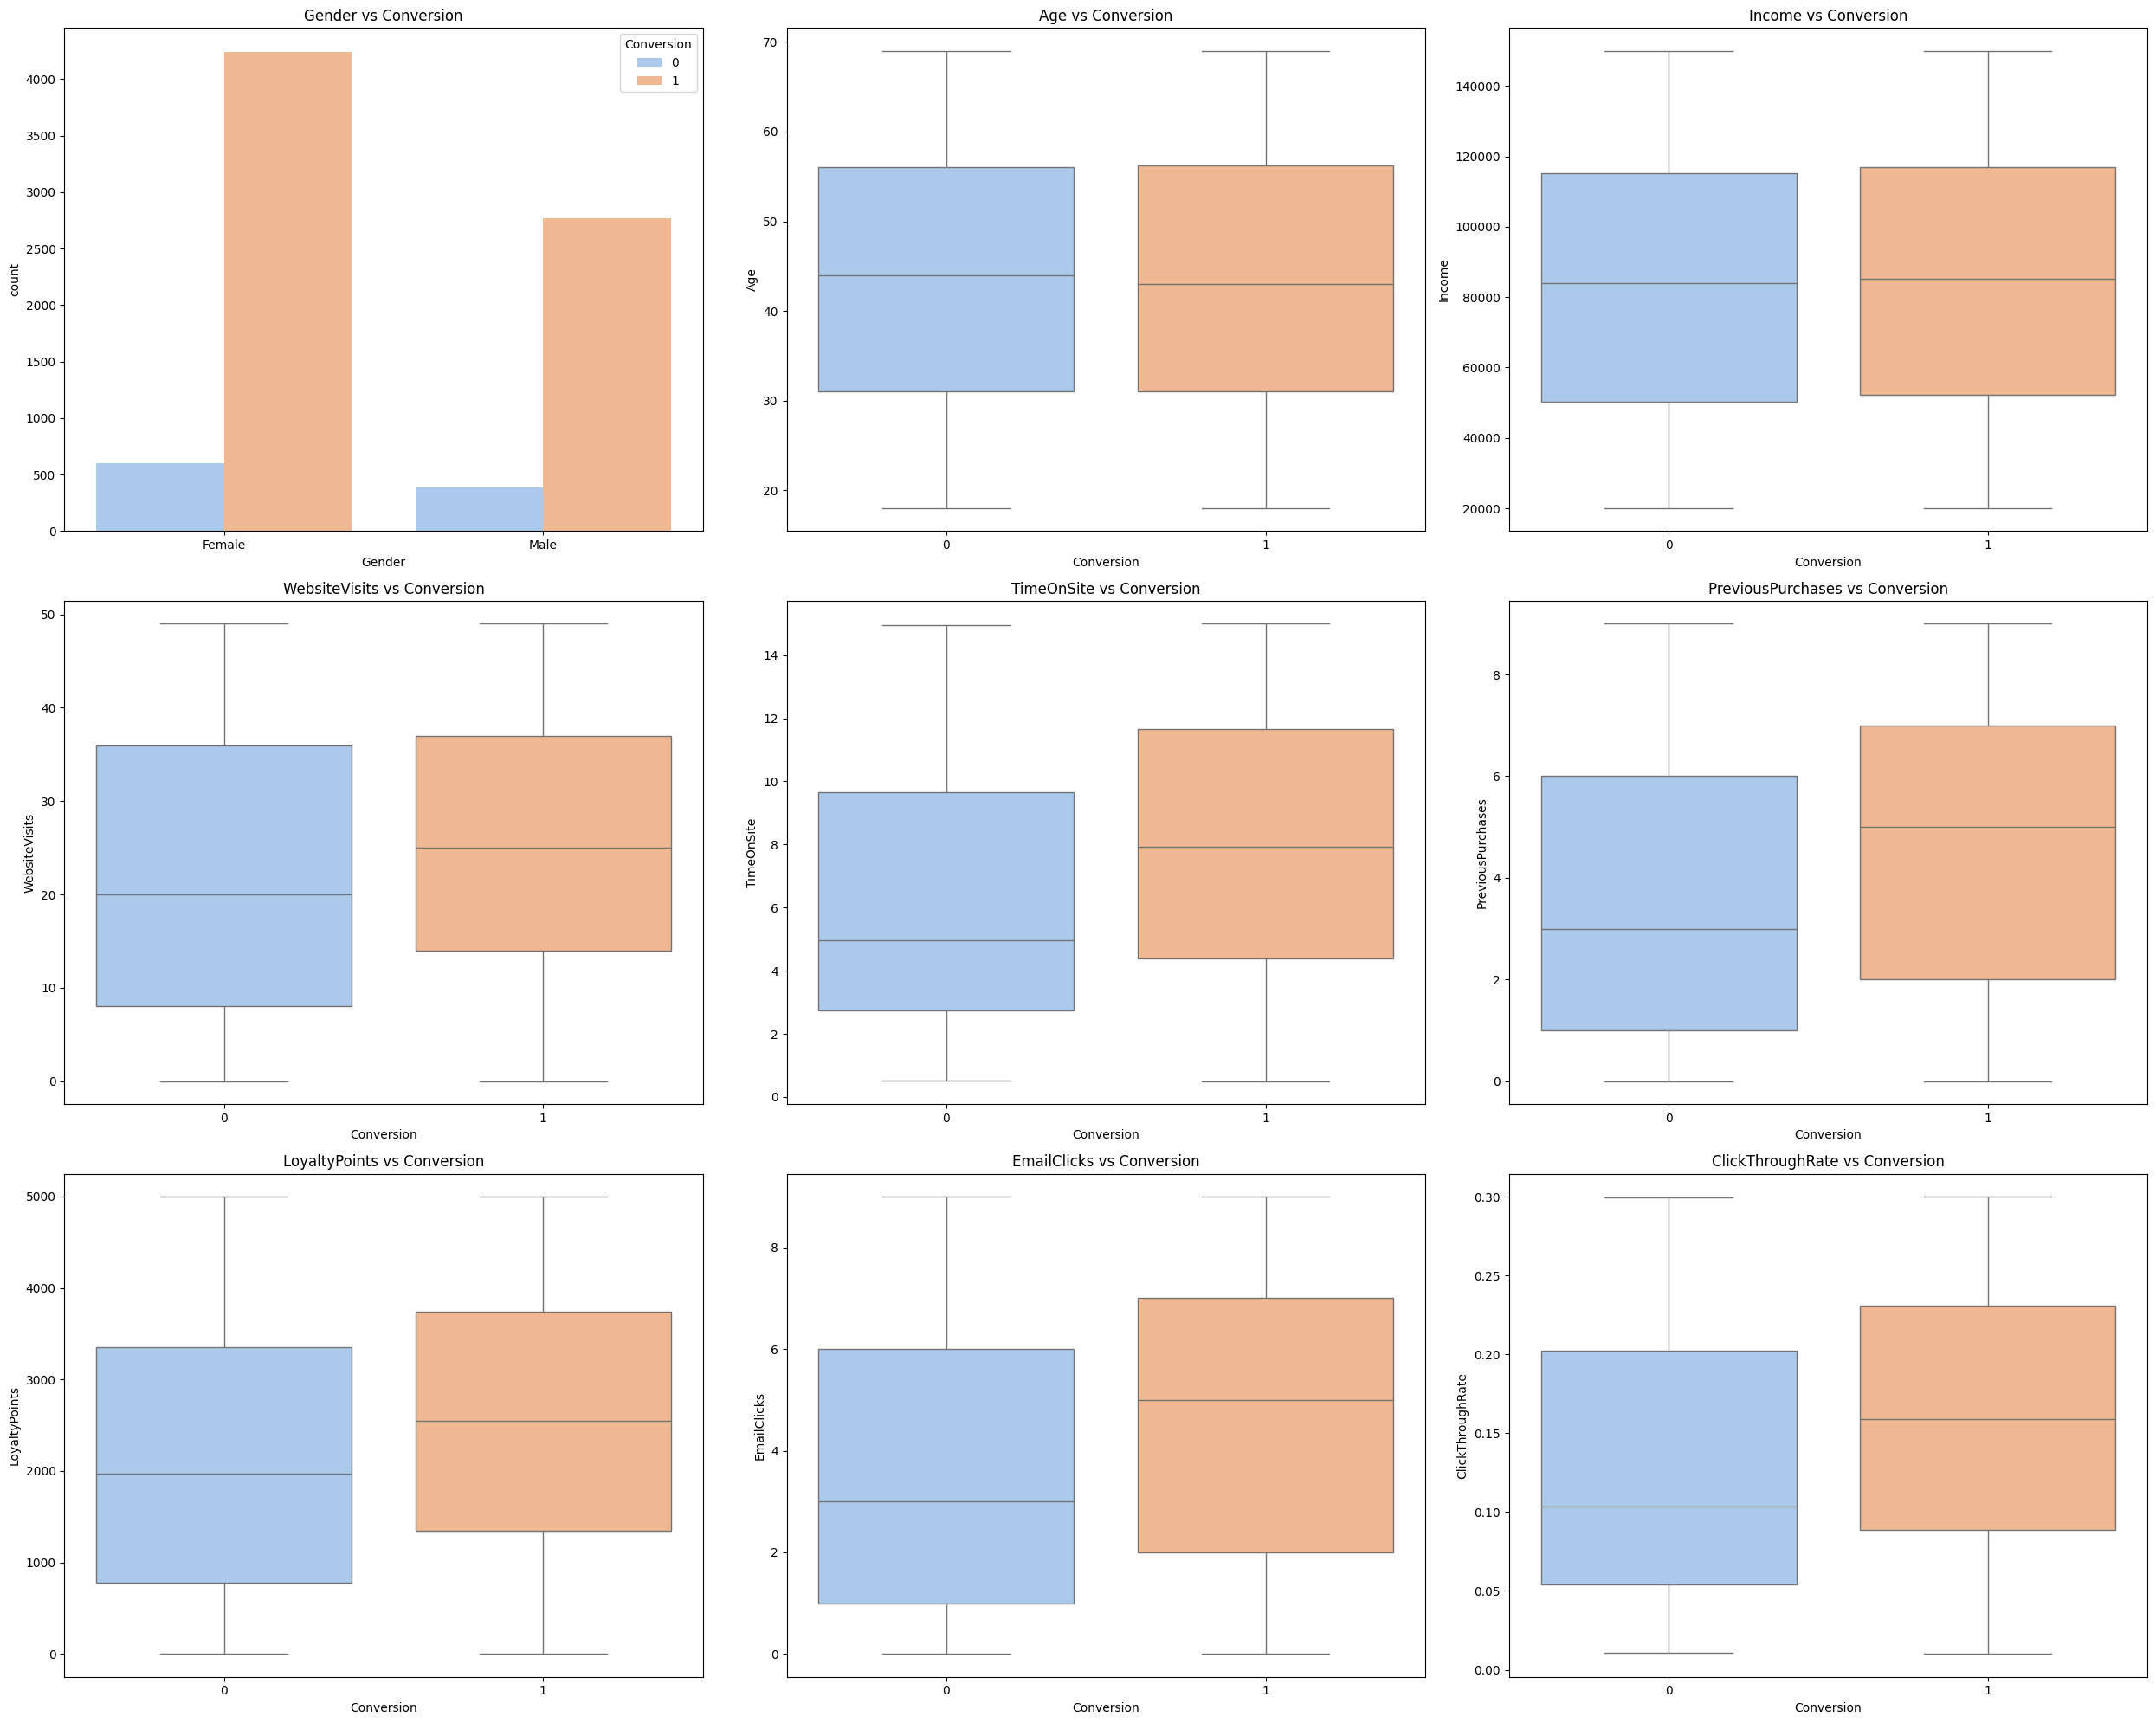

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(25, 20))
axes = axes.flatten()

sns.countplot(data=df, x="Gender", hue="Conversion", palette="pastel", ax=axes[0])
axes[0].set_title("Gender vs Conversion")

customer_demographic = ["Age","Income","WebsiteVisits","TimeOnSite","PreviousPurchases","LoyaltyPoints","EmailClicks","ClickThroughRate"]

for i, v in enumerate(customer_demographic):
    sns.boxplot(data=df, x='Conversion', y=v, ax=axes[i+1], hue='Conversion', palette="pastel", legend=False)
    axes[i+1].set_title(f'{v} vs Conversion')

plt.tight_layout()
plt.show()

**Conclusion:** <br>
- **Gender:** the countplot reveals that female customers have a significantly higher frequency of conversion, compared to their male partner.

- **Age & Income:** the distribution of age and income are identical, and it gives no insights. Therefore, we should avoid doing further analysis on these two variables.

- **Website Visits:** here is a slightly visible upward shift in the box plot for the converted group. Users who convert tend to have a higher median number of visits.

- **Time On site:** There is a significant difference between two groups. The converted group have a significantly higher time spent on a website in comparision to the non-converted group.

- **Loyalty Point & Previous repurchase:** also shows that loyal customer tend to repond to the marketing campaign

- **Email Clicks and Click Through rate:** both shows that the converted group shows a higher click Through rate. The median for both variables in the converted groups are noticeably higher.

## **5. Analysis for Campaign's metrics and conversion**

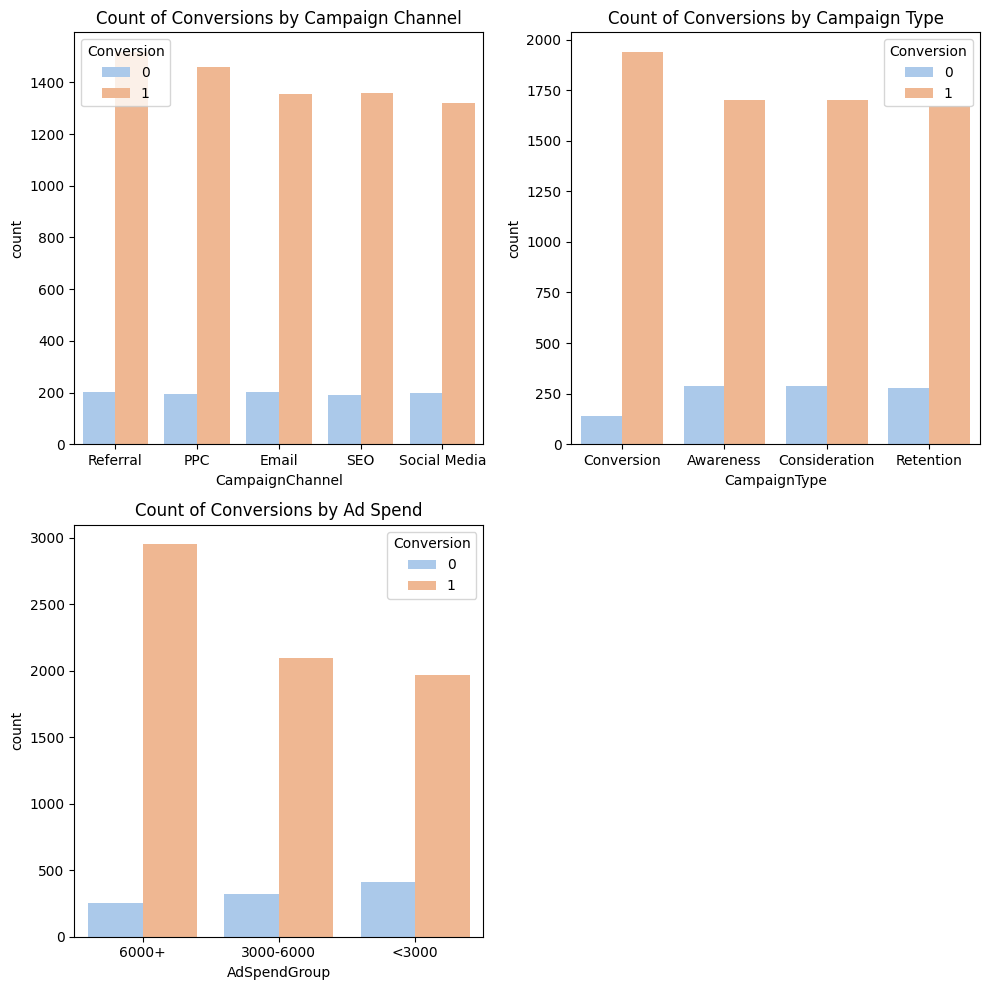

In [9]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
axes = axes.flatten()

sns.countplot(
    data=df, x='CampaignChannel', ax=axes[0], hue='Conversion',
    order=df['CampaignChannel'].value_counts().index,
    palette="pastel"
)
axes[0].set_title('Count of Conversions by Campaign Channel')


sns.countplot(
    data=df, x='CampaignType', ax=axes[1], hue='Conversion',
    order=df['CampaignType'].value_counts().index,
    palette="pastel"
)
axes[1].set_title('Count of Conversions by Campaign Type')


df['AdSpendGroup'] = pd.cut(df['AdSpend'],bins = [0,3000,6000,10000] , labels = ["<3000", "3000-6000","6000+"])
sns.countplot(
    data=df, x='AdSpendGroup', ax=axes[2], hue='Conversion',
    order=df['AdSpendGroup'].value_counts().index,
    palette="pastel"
)
axes[2].set_title('Count of Conversions by Ad Spend')

fig.delaxes(axes[3])

plt.tight_layout()
plt.show()



**Conclusion:** <br>
- **Campaign Type:** The "Conversion" campaign type has the highest number of successful conversions and the lowest number of non-conversions compared to Awareness or Retention.
- **Campaign channel:** are relatively stable across all channels. However, Referral and PPC show a slight edge in total conversion volume.
- **Ad Spend Group:** There is a clear "Pay-to-win" relationship. The 6000+ spend group has the highest conversion count, while the least invested group received lowest conversion count.

## **6. Heatmap for correlation**

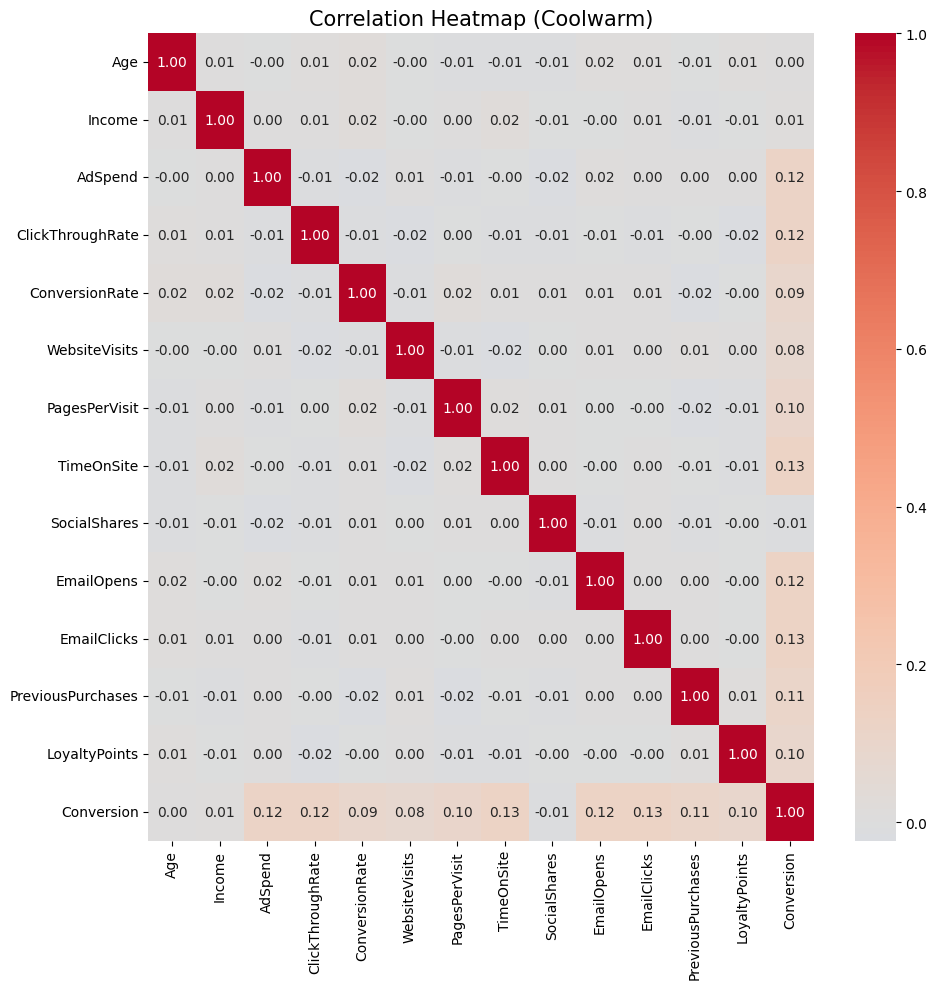

In [10]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt=".2f", center=0)
plt.title('Correlation Heatmap (Coolwarm)', fontsize=15)
plt.tight_layout()
plt.show()

**Conclusion:** There is no `Multicollinearity` issue in the selected features. All correlation coefficients between independent variables are very low ($|r| < 0.1$), indicating that the features are independent of each other.

## **7. Outlier Detection (IQR Method)**


In [11]:

# Detect outliers for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=["Conversion"]).columns
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({
        "variable" : col,
        "total outlier" : len(outliers)
    })

print("Number of outlier detected in each variable")
pd.DataFrame(outlier_summary)


Number of outlier detected in each variable


,variable,total outlier
0,Age,0
1,Income,0
2,AdSpend,0
3,ClickThroughRate,0
4,ConversionRate,0
5,WebsiteVisits,0
6,PagesPerVisit,0
7,TimeOnSite,0
8,SocialShares,0
9,EmailOpens,0


**Conclusion:** There is no outliers in the quantitative data. 